# The Bona-Smith system, a solitary wave reflected by a wall

We solve the Bona-Smith system of Boussinesq equations

$$\begin{aligned}
\eta_t + u_x + (\eta u)_x - b\,\eta_{xxt} &= 0,\\
u_t + \eta_x + u\,u_x + c\,\eta_{xxx} - d\,u_{xxt} &= 0,
\end{aligned} \qquad 0 < x < L, \quad 0 < t \le T,$$

for the free surface elevation $\eta$ and the horizontal velocity $u$, with

$$b = d = \frac{3\theta^2 - 1}{6}, \qquad c = \frac{2 - 3\theta^2}{3}, \qquad \frac{2}{3} < \theta^2 \le 1.$$

At both ends there is a vertical wall, so the boundary conditions are

$$\eta_x(0, t) = \eta_x(L, t) = 0, \qquad u(0, t) = u(L, t) = 0.$$

For $\theta^2 = 9/11$, that is $b = d = 8/33$ and $c = -5/33$, the system has the exact solitary wave

$$\eta(x, t) = \mathrm{sech}^2\left(\lambda\,(x - x_0 - c_s t)\right), \qquad u = \frac{\sqrt{3}}{2}\,\eta, \qquad \lambda = \frac{\sqrt{165}}{20}, \quad c_s = \frac{5\sqrt{3}}{6},$$

as one checks by substituting it into the equations. We start it at $x_0 = 30$ in $[0, 100]$. It travels to the right, hits the wall at $x = 100$ at about $t = 48.5$, and is reflected back.

**The weak form.** We multiply the first equation by a test function $\phi$ and the second by $\chi$, and integrate the terms $\eta_{xxt}$, $u_{xxt}$ and $\eta_{xxx}$ by parts once. The boundary term $b\,\eta_{xt}\phi$ vanishes because $\eta_x = 0$ at the walls, so the condition on $\eta$ is natural and $\phi$ is free at the ends. The boundary terms of the second equation vanish because $u = 0$ is built into the space of $u$ and so $\chi = 0$ at the ends. This gives

$$\begin{aligned}
\int \left(\eta_t\,\phi + b\,\eta_{xt}\,\phi'\right) dx &= -\int (u + \eta u)_x\,\phi \, dx,\\
\int \left(u_t\,\chi + d\,u_{xt}\,\chi'\right) dx &= -\int \left(\eta_x + u\,u_x\right) \chi \, dx + c \int \eta_{xx}\,\chi' \, dx.
\end{aligned}$$

As in `example3`, in the spline spaces this is a system $M\,c'(t) = f(c)$ of ordinary differential equations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx

In [2]:
theta2 = 9 / 11
b = d = (3 * theta2 - 1) / 6                      # 8/33
c = (2 - 3 * theta2) / 3                          # -5/33

cs, lam, x0 = 5 * np.sqrt(3) / 6, np.sqrt(165) / 20, 30.0

def exact(x, t, cosh=np.cosh):
    """The solitary wave eta at time t. x is an array (cosh=np.cosh) or fd.x (cosh=fd.cosh)."""
    return 1 / cosh(lam * (x - x0 - cs * t))**2

Cubic splines on 400 equal elements of $[0, 100]$, one space for each unknown. The space of $\eta$ is `"free"`, since $\eta_x = 0$ is a natural condition, and the space of $u$ has $u = 0$ built in at both ends. `fd.ProductSpace` puts them together for the system.

In [3]:
grid = np.linspace(0, 100, 1001)
Veta = fd.SplineSpace(grid, 3, bc="free")
Vu = fd.SplineSpace(grid, 3, bc="dirichlet")
W = fd.ProductSpace(Veta, Vu)

(eta, u), (phi, chi) = fd.TrialFunctions(W), fd.TestFunctions(W)

The solution is a `ProductFunction` of `W`, one coefficient vector for both unknowns. Unpacked as `h, v = w`, its two fields enter the forms. It starts as the $L^2$ projection of the solitary wave, field by field.

In [4]:
w = fd.Functions(W, "w")
eta0 = exact(fd.x, 0.0, fd.cosh)
w.project([eta0, np.sqrt(3) / 2 * eta0])
h, v = w                                          # eta and u, for the forms

The two sides of the weak form, `M` bilinear in the trial and test functions and `f` nonlinear in `w`.

With these boundary conditions the system conserves the mass $\int \eta\,dx$ and the energy $E = \frac{1}{2}\int \left(\eta^2 + (1 + \eta)\,u^2 - c\,\eta_x^2\right) dx$. We check both.

In [5]:
M = fd.form((eta * phi + b * D(eta) * D(phi) + u * chi + d * D(u) * D(chi)) * dx)
f = fd.form((-D(v + h * v) * phi - (D(h) + v * D(v)) * chi + c * D(h, 2) * D(chi)) * dx)

mass = fd.form(h * dx)
energy = fd.form(0.5 * (h**2 + (1 + h) * v**2 - c * D(h)**2) * dx)
mass0, E0 = mass.assemble(), energy.assemble()
print("mass =", mass0, "  energy =", E0)

mass = 3.1139957766460933   energy = 2.491196621334659


Classical RK4 with $\Delta t = 0.05$, as in `example3`. Until about $t = 25$ the wave is far from both walls, so we can compare with the exact solitary wave there.

In [6]:
dt = 0.05
rk = fd.ERK(M, f, dt, "rk4")
for n in range(int(round(25 / dt))):
    rk.step(w)

t = rk.t
xs = np.linspace(0, 100, 4001)
eh, uh = w.split()                                # the two fields as Functions
print("t =", t)
print("max error in eta:", np.max(np.abs(eh(xs) - exact(xs, t))))
print("max error in u:  ", np.max(np.abs(uh(xs) - np.sqrt(3) / 2 * exact(xs, t))))

t = 25.00000000000022
max error in eta: 7.194236585017499e-06
max error in u:   6.404123271686046e-06


Now the reflection. We continue to $T = 100$, keep the free surface every 25 time units, and record the elevation at the wall, $\eta(100, t)$, at every step. At the wall the wave rises above its amplitude, then separates from the wall and travels back to the left, leaving a small dispersive tail behind.

The mass is conserved to rounding. The energy is conserved by the equations, and its computed value changes only by the discretization error, about $5\cdot 10^{-4}$ here and ten times less on 800 elements with $\Delta t = 0.025$. The maximum elevation at the wall converges to about $2.2755$.

In [7]:
T = 100.0
snapshots = {0.0: exact(xs, 0.0), 25.0: eh(xs)}
times, at_wall = [rk.t], [eh(np.array([100.0]))[0]]
while rk.t < T - dt / 2:
    rk.step(w)
    eh, uh = w.split()
    times.append(rk.t); at_wall.append(eh(np.array([100.0]))[0])
    if abs(rk.t / 25 - round(rk.t / 25)) < 1e-9:
        snapshots[round(rk.t)] = eh(xs)

k = int(np.argmax(at_wall))
print(f"maximum elevation at the wall: {at_wall[k]:.4f} at t = {times[k]:.2f}")
print("change in mass:  ", abs(mass.assemble() - mass0))
print("change in energy:", abs(energy.assemble() - E0))

maximum elevation at the wall: 2.2748 at t = 48.65
change in mass:   4.884981308350689e-15
change in energy: 1.5161204943492379e-05


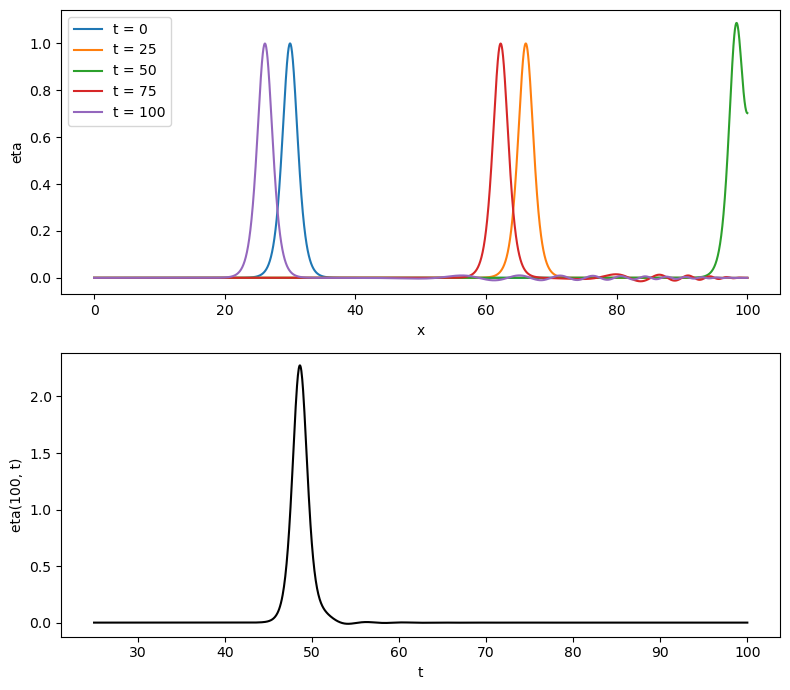

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7))
for tk, eta_k in snapshots.items():
    ax[0].plot(xs, eta_k, label=f"t = {tk:g}")
ax[0].set_xlabel("x"); ax[0].set_ylabel("eta"); ax[0].legend()
ax[1].plot(times, at_wall, "k-")
ax[1].set_xlabel("t"); ax[1].set_ylabel("eta(100, t)")
plt.tight_layout()
plt.show()